# Valutazione del modello formale

Questo notebook analizza il comportamento del modello di scheduling policy-driven
descritto nel Capitolo 3, eseguito attraverso l'implementazione di riferimento in
Python. L'obiettivo non è misurare tempi di esecuzione — quelli dipendono
dall'infrastruttura e vengono misurati separatamente sul prototipo Kubernetes — ma
caratterizzare **quanto le politiche restringono lo spazio delle soluzioni** e
**come lo stato accumulato sui nodi ne fa evolvere l'ammissibilità**.

L'analisi è divisa in due parti, che corrispondono a due domande distinte.

**Parte I — Lo spazio delle soluzioni.** Ogni task viene valutato singolarmente su
un cluster pulito e inattivo: nessuna impronta contestuale, nessun nodo occupato,
nessuna sanificazione in corso. Quello che si misura è una proprietà della
*configurazione*: quanto le politiche `c_prop`, `c_geo` e `c_static` riducono
l'insieme dei nodi ammissibili, singolarmente e in composizione.

**Parte II — La dinamica dell'assegnazione.** Lo stesso carico viene eseguito come
sequenza ordinata, lasciando evolvere le due sole variabili di stato del sistema:
l'impronta contestuale `Λ(n)` lasciata dai task e l'occupazione dei nodi. Quello che
si misura è l'effetto dello *stato*: quanto la politica di Chinese Wall blocca, come
la sanificazione lo mitiga, e quanto la ridondanza dei nodi aiuta.

Tenere separate le due parti è ciò che permette di attribuire un risultato o alla
composizione del cluster o allo stato accumulato, invece che a una miscela
indistinguibile dei due.

## Metodologia

**Il passo come unità.** Nella Parte II un passo corrisponde a un task sottomesso.
Non è un'unità di tempo: la durata dei task e il periodo di sanificazione sono
espressi in passi, e le latenze assolute non vengono mai stimate qui. Misurare
millisecondi richiederebbe di simulare code, backoff e latenze di rete, cioè di
modellare il prototipo invece di misurarlo.

**Task bloccati.** Un task che al proprio passo non trova alcun nodo ammissibile
viene contato come bloccato e non viene riprovato. Riprovarlo introdurrebbe una
coda, che è comportamento del prototipo. Qui si misura l'ammissibilità istantanea:
se lo stato lasciato dai task precedenti consente a questo di partire.

**Ripetizioni.** Ogni configurazione è eseguita con 10 semi indipendenti, che
determinano composizione del cluster, attributi e piazzamento dei dataset, grafo dei
conflitti e ordine del batch. I grafici riportano la **mediana** fra i semi e, dove
utile, la banda fra minimo e massimo: le distribuzioni sono spesso asimmetriche e la
media sarebbe fuorviante.

**Isolamento delle variabili.** Ogni ambito attinge da un flusso pseudocasuale
indipendente, quindi cambiare il numero di task non altera il cluster e cambiare la
densità di conflitto non altera i dataset. Ogni esperimento fa variare un solo asse
rispetto a una configurazione di riferimento comune.

**I requisiti sono estratti da livelli pesati.** Ogni proprietà ha tre livelli, e
sia i task sia i dataset dichiarano per ciascuna un livello richiesto, estratto con
pesi decrescenti: il livello massimo è raro, non impossibile. Questo è necessario
perché `β*(t)` è un minimo maggiorante su tutte le proprietà di tutti i dataset
richiesti, quindi aggrega fino a nove estrazioni indipendenti: un livello estratto
raramente per singolo dataset diventa comune a livello di task. Con un tetto rigido
il livello massimo sarebbe stato o impossibile o tipico, senza vie di mezzo.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

RESULTS = Path(".tmp/results")
FIGURES = Path(".tmp/figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (7.6, 4.2),
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "font.size": 10,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
})

# Palette usata in modo coerente in tutto il notebook.
BLU, ARANCIO, VERDE, ROSSO, VIOLA, GRIGIO = (
    "#2f6f9f", "#e08214", "#4a9e5c", "#c0392b", "#7b5ea7", "#8a8a8a")

TRANSLATION_CAUSES = {"auth", "geo_empty", "static_empty"}
ETICHETTE_TEMPLATE = {
    "flat": "piatto", "stratified": "stratificato", "realistic": "realistico"}


# Carica un file di risultati e vi aggiunge le colonne derivate usate nei grafici.
def load(name):
    df = pd.read_csv(RESULTS / f"{name}.csv")
    if "cause" not in df.columns:
        return df

    df["rifiutato_in_traduzione"] = df.cause.isin(TRANSLATION_CAUSES)
    for cause in ("prop", "geo", "static", "wall", "capacity", "sanitizing",
                  "geo_empty", "static_empty"):
        df[f"causa_{cause}"] = df.cause == cause

    ispezionati = ~df.rifiutato_in_traduzione
    for col, src in (("frazione_prop", "n_after_prop"),
                     ("frazione_geo", "n_after_geo"),
                     ("frazione_static", "n_after_static"),
                     ("frazione_ammissibili", "n_admissible")):
        df[col] = np.where(ispezionati, df[src] / df.n_nodes, np.nan)

    df["richiede_statici"] = df.n_static_datasets > 0
    return df


# Aggrega per configurazione e seme: una riga per ogni run.
def per_seed(df, keys, metrics):
    return df.groupby(keys + ["seed"], observed=True).agg(**metrics).reset_index()


# Mediana fra i semi, con minimo e massimo per rappresentare la dispersione.
def mediana_e_banda(per_seed_df, keys, column):
    g = per_seed_df.groupby(keys, observed=True)[column]
    return g.agg(mediana="median", minimo="min", massimo="max").reset_index()


# Traccia una curva con banda di dispersione fra i semi.
def curva(ax, per_seed_df, x, y, colore, etichetta, marker="o", stile="-"):
    b = mediana_e_banda(per_seed_df, [x], y).sort_values(x)
    ax.plot(b[x], b.mediana, stile, marker=marker, color=colore, label=etichetta)
    ax.fill_between(b[x], b.minimo, b.massimo, color=colore, alpha=0.13, linewidth=0)
    return b


def percentuale(ax, asse="y", decimali=0):
    fmt = PercentFormatter(xmax=1, decimals=decimali)
    (ax.yaxis if asse == "y" else ax.xaxis).set_major_formatter(fmt)


def salva(fig, nome):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{nome}.pdf")
    fig.savefig(FIGURES / f"{nome}.png")

---

# Parte I — Lo spazio delle soluzioni

Le politiche del modello agiscono in due punti diversi della pipeline, e la
distinzione è importante perché le due situazioni si correggono in modo opposto.

Alcune rifiutano il task **in traduzione**, prima ancora che un nodo venga
esaminato. È il caso di `geo*(t) = ∅`, quando i dataset richiesti sono soggetti a
giurisdizioni la cui intersezione è vuota, e dell'intersezione vuota dei nodi che
ospitano localmente i dataset statici. Un rifiuto di questo tipo dipende solo dalla
richiesta: nessuna quantità di nodi aggiuntivi lo risolve.

Altre agiscono **in filtraggio**, escludendo nodi uno per uno. Qui il problema è la
composizione del cluster, e aggiungere nodi adeguati aiuta.

## Quanto ciascuna politica restringe l'insieme dei nodi ammissibili

**Che cosa si calcola.** Le politiche vengono valutate in ordine fisso — prima
`c_prop`, poi `c_geo`, poi `c_static` — e ogni nodo escluso è attribuito alla prima
politica che non soddisfa. Il conteggio dopo ciascuna politica è quindi il numero
di nodi sopravvissuti a quella e a tutte le precedenti: la sequenza si legge come un
imbuto, dove ogni curva sta necessariamente sotto la precedente.

**Che cosa si fa variare.** La cardinalità di `req(t)`, cioè quanti dataset ciascun
task richiede, da 1 a 5, su tre composizioni di cluster: uno *piatto*, in cui tutti
i nodi offrono il livello massimo di ogni proprietà; uno *stratificato*, con le
classi distribuite uniformemente sul reticolo; e uno *realistico*, sbilanciato verso
i livelli bassi con pochi nodi di fascia alta.

**Perché il numero di dataset è la variabile giusta.** È l'unico parametro fra
quelli in gioco che dipende da chi scrive il task, e non da chi amministra il
cluster: il numero di nodi, le loro classi e la posizione dei dati sono decisioni
dell'operatore, mentre quante sorgenti un task aggrega è una scelta dell'utente.
Misurarne l'effetto produce quindi una raccomandazione azionabile da chi usa il
sistema.

**Perché ci si aspetta un andamento decrescente, prima di misurarlo.** Non è
un'ipotesi da verificare ma una conseguenza algebrica degli operatori del modello.
Il requisito effettivo `β*(t)` è un minimo maggiorante sui dataset richiesti, e
aggiungere un elemento non può abbassare un massimo; `geo*(t)` e l'intersezione dei
nodi che ospitano i dataset statici sono intersezioni, e aggiungere un insieme non
può allargare un'intersezione. Ne segue che per ogni task e per ogni dataset
aggiuntivo l'insieme ammissibile può solo restringersi, **qualunque sia la
distribuzione dei dati**. L'esperimento non serve dunque a stabilire *se* il pool si
restringa, ma *quanto*, che è una grandezza legittimamente dipendente dal carico.

**Disegno appaiato.** Per questa ragione le richieste di dimensione diversa non sono
campioni indipendenti: ogni task è generato con cinque dataset e valutato sui
prefissi di lunghezza 1, 2, ... della *propria* lista. Il confronto tiene quindi
fissi il task, l'issuer e i dataset, e aggiunge un vincolo alla volta. Un disegno non
appaiato avrebbe mescolato l'effetto in esame con la varianza fra campioni diversi,
e con essa la monotonia attesa.

**Un campione costante.** Un task può essere rifiutato in traduzione — perché
`geo*(t)` si svuota o perché i dataset statici non hanno nodi in comune — e in quel
caso nessun nodo viene esaminato, quindi non contribuisce all'imbuto. Poiché il
rifiuto è monotono nella lunghezza del prefisso, un task che sopravvive al prefisso
più lungo sopravvive a tutti quelli più corti: restringere l'analisi a questi task dà
un campione **identico** a ogni lunghezza. Senza questo accorgimento la curva
sarebbe calcolata su un insieme progressivamente più piccolo e più "facile", perché
i task via via rifiutati sono proprio i più vincolati. La quota di task rifiutati in
traduzione è riportata a parte, perché è essa stessa un risultato.

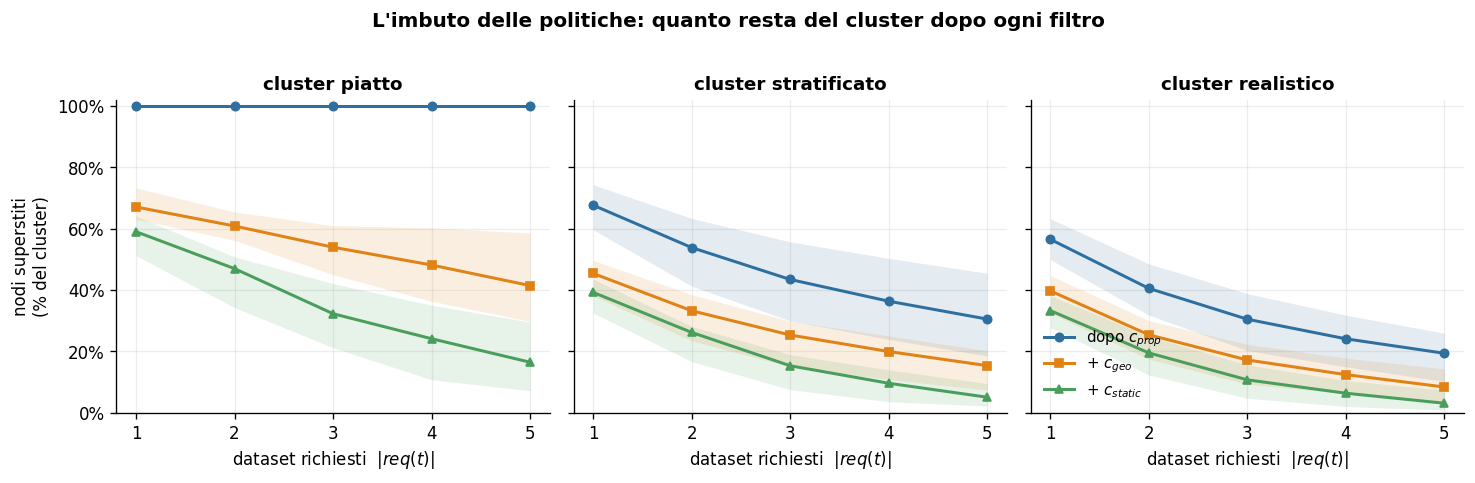

Frazione di nodi superstiti dopo ciascuna politica (mediana su 10 semi,
campione appaiato e costante)

                          prop    geo  static
template     n_datasets                      
piatto       1           1.000  0.671   0.590
             2           1.000  0.609   0.470
             3           1.000  0.540   0.323
             4           1.000  0.482   0.241
             5           1.000  0.415   0.165
realistico   1           0.565  0.397   0.333
             2           0.405  0.254   0.195
             3           0.305  0.172   0.107
             4           0.241  0.124   0.063
             5           0.194  0.084   0.031
stratificato 1           0.677  0.454   0.392
             2           0.539  0.332   0.262
             3           0.434  0.253   0.153
             4           0.364  0.199   0.096
             5           0.305  0.153   0.050


In [4]:
d = load("policy_funnel_tasks")
MAX_PREFIX = int(d.n_datasets.max())

# Campione costante: i task che superano la traduzione al prefisso più lungo la
# superano a ogni lunghezza, perché il rifiuto in traduzione è monotono.
superstiti = (d[(d.n_datasets == MAX_PREFIX) & (~d.rifiutato_in_traduzione)]
              [["template", "seed", "task"]].drop_duplicates())
appaiato = d.merge(superstiti, on=["template", "seed", "task"])

ps = per_seed(appaiato, ["template", "n_datasets"], dict(
    prop=("frazione_prop", "mean"),
    geo=("frazione_geo", "mean"),
    static=("frazione_static", "mean"),
))

fig, assi = plt.subplots(1, 3, figsize=(12.4, 3.9), sharey=True)
serie = [("prop", r"dopo $c_{prop}$", BLU, "o"),
         ("geo", r"$+\ c_{geo}$", ARANCIO, "s"),
         ("static", r"$+\ c_{static}$", VERDE, "^")]

for ax, template in zip(assi, ["flat", "stratified", "realistic"]):
    sub = ps[ps.template == template]
    for colonna, nome, colore, marker in serie:
        curva(ax, sub, "n_datasets", colonna, colore, nome, marker=marker)
    ax.set_title(f"cluster {ETICHETTE_TEMPLATE[template]}")
    ax.set_xlabel("dataset richiesti  $|req(t)|$")
    ax.set_xticks(range(1, MAX_PREFIX + 1))
    ax.set_ylim(0, 1.02)
    percentuale(ax)

assi[0].set_ylabel("nodi superstiti\n(% del cluster)")
assi[2].legend(loc="lower left")
fig.suptitle("L'imbuto delle politiche: quanto resta del cluster dopo ogni filtro",
             y=1.02, fontsize=12, fontweight="semibold")
salva(fig, "imbuto_politiche")
plt.show()

tab = ps.groupby(["template", "n_datasets"])[["prop", "geo", "static"]].median().round(3)
tab.index = tab.index.set_levels(
    [ETICHETTE_TEMPLATE[t] for t in tab.index.levels[0]], level=0)
print("Frazione di nodi superstiti dopo ciascuna politica (mediana su 10 semi,\n"
      "campione appaiato e costante)\n")
print(tab)

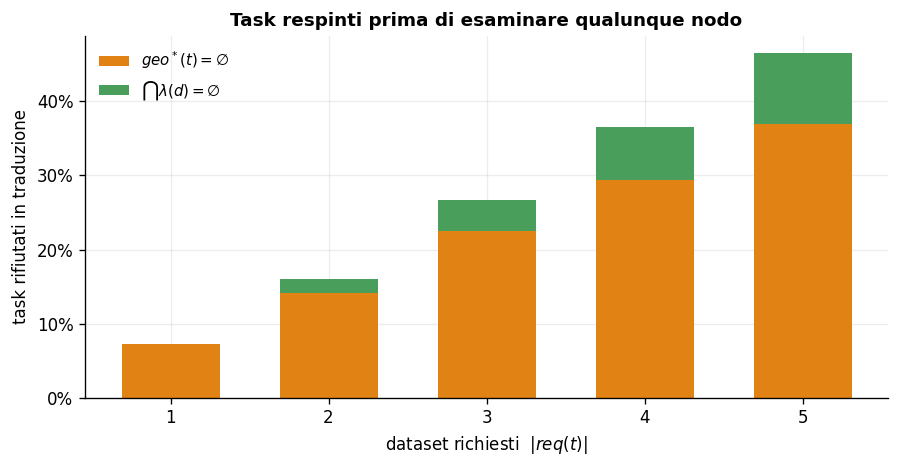

Rifiuti in traduzione per lunghezza della richiesta (mediana su 10 semi)

            rifiutati  geo_vuoto  statici_vuoti
n_datasets                                     
1               0.073      0.073          0.000
2               0.186      0.142          0.019
3               0.293      0.224          0.042
4               0.419      0.294          0.072
5               0.526      0.370          0.096


In [5]:
# La mortalità in traduzione, riportata a parte: non entra nell'imbuto ma è
# essa stessa un vincolo del modello.
mort = per_seed(d, ["n_datasets"], dict(
    rifiutati=("rifiutato_in_traduzione", "mean"),
    geo_vuoto=("causa_geo_empty", "mean"),
    statici_vuoti=("causa_static_empty", "mean"),
))

fig, ax = plt.subplots(figsize=(7.6, 4.0))
x = np.arange(1, MAX_PREFIX + 1)
base = np.zeros(MAX_PREFIX)
for colonna, nome, colore in (("geo_vuoto", r"$geo^*(t) = \emptyset$", ARANCIO),
                              ("statici_vuoti", r"$\bigcap \lambda(d) = \emptyset$", VERDE)):
    val = mort.groupby("n_datasets")[colonna].median().reindex(x).values
    ax.bar(x, val, 0.62, bottom=base, color=colore, label=nome)
    base += val
ax.set_xlabel("dataset richiesti  $|req(t)|$")
ax.set_ylabel("task rifiutati in traduzione")
ax.set_xticks(x)
percentuale(ax)
ax.legend(loc="upper left")
ax.set_title("Task respinti prima di esaminare qualunque nodo")
salva(fig, "imbuto_mortalita")
plt.show()

print("Rifiuti in traduzione per lunghezza della richiesta (mediana su 10 semi)\n")
print(mort.groupby("n_datasets")[["rifiutati", "geo_vuoto", "statici_vuoti"]]
      .median().round(3))

**Che cosa indicano i grafici.** Nel primo, ogni pannello è una composizione di
cluster e le tre curve sono cumulative: la blu è la frazione di nodi che superano
`c_prop`, l'arancio quelli che superano `c_prop` **e** `c_geo`, la verde quelli che
superano tutte e tre. La distanza verticale fra due curve adiacenti è il contributo
della singola politica, e la banda ombreggiata copre l'intervallo fra il seme
migliore e il peggiore. Il secondo grafico riporta la quota di task che non arrivano
nemmeno al filtraggio, scomposta per causa.

**Risultato.** Le curve sono monotone decrescenti in tutti i template, come la
struttura degli operatori impone, e la monotonia vale esattamente task per task: sui
record appaiati non si registra alcuna violazione, e una violazione segnalerebbe un
errore di implementazione, non un fenomeno.

Il contributo delle tre politiche non è uniforme. Nel cluster piatto `c_prop` non
esclude nulla per costruzione — la curva blu resta al 100% — e tutta la riduzione è
imputabile a `c_geo` e `c_static`: dal 66% al 17% dei nodi fra uno e cinque dataset.
Nei cluster differenziati `c_prop` diventa il filtro dominante già a una singola
richiesta, e con cinque dataset il pool complessivo scende al 6% nello stratificato e
al 4% nel realistico.

Il secondo grafico mostra un vincolo che l'imbuto da solo nasconde: la quota di task
respinti in traduzione cresce dal 5% con un dataset al 55% con cinque, e le due
cause pesano in modo diverso — l'intersezione geografica vuota domina ai prefissi
brevi, quella dei dataset statici cresce più rapidamente. È un limite indipendente
dalla composizione del cluster, come si vede dal fatto che i tre template danno
valori quasi identici.

**Conclusione da trarne.** Il numero di dataset per task è una leva di
dimensionamento tanto quanto l'eterogeneità del cluster, e agisce su due fronti
distinti: restringe il pool per i task che restano ammissibili e ne rende
inammissibili una quota crescente. Poiché entrambi gli effetti seguono dalla
definizione degli operatori del modello, sono strutturali e non dipendono dalle
distribuzioni adottate: queste ne determinano la pendenza, non la direzione. In fase
di progetto conviene quindi limitare l'aggregazione di sorgenti eterogenee in un
singolo task, oppure accettare che tali task abbiano un insieme di collocazioni molto
ristretto.

## Residenza dei dati statici e fattore di replica

**Che cosa si calcola.** I dataset marcati come statici non possono essere
trasferiti: il task deve raggiungerli dove si trovano. Quando un task ne richiede
più d'uno, i nodi candidati sono quelli che li ospitano **tutti** localmente, cioè
l'intersezione degli insiemi `λ(d)`. Se l'intersezione è vuota il task viene
rifiutato in traduzione, prima che qualunque nodo venga esaminato. Si misura la
frequenza di questo rifiuto e l'effetto complessivo sui task assegnati.

**Che cosa si fa variare.** Due parametri, su una griglia completa: la frazione di
dataset statici nella popolazione (da 0 a 1) e il numero di nodi su cui ciascun
dataset è replicato (da 1 a 5). Il primo determina quanto spesso il vincolo si
applica, il secondo quanto è probabile che esista un'intersezione non vuota.

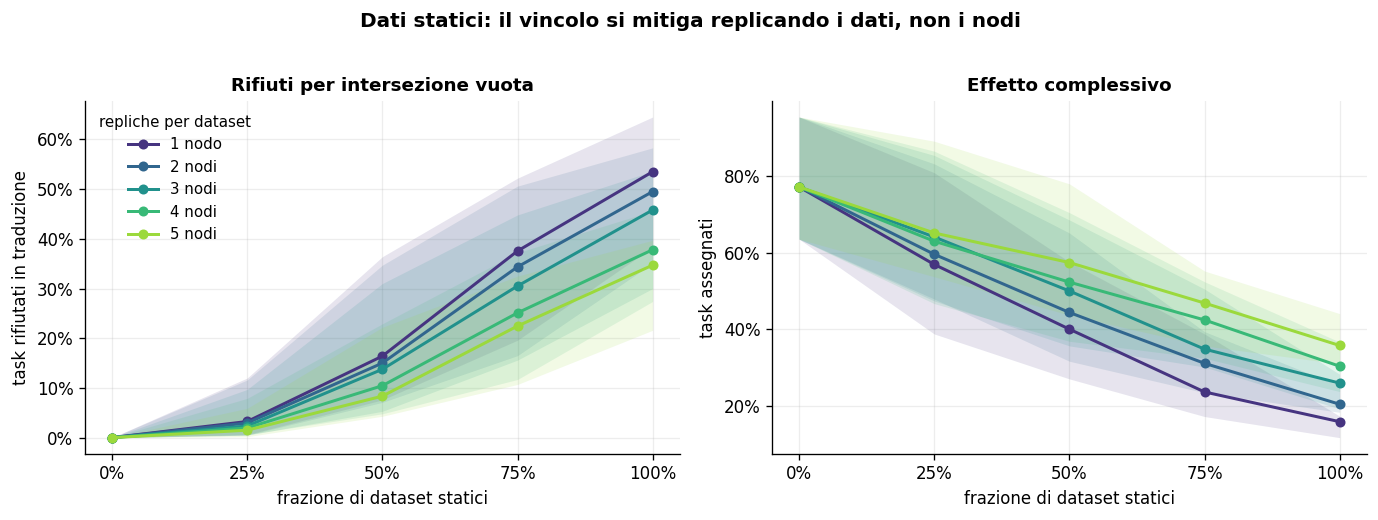

Rifiuti per intersezione vuota (mediana su 10 semi)

repliche              1      2      3      4      5
frazione statici                                   
0.00              0.000  0.000  0.000  0.000  0.000
0.25              0.032  0.030  0.024  0.020  0.015
0.50              0.164  0.150  0.138  0.104  0.083
0.75              0.376  0.344  0.305  0.251  0.224
1.00              0.535  0.495  0.458  0.378  0.347


In [6]:
d = load("static_data_tasks")
ps = per_seed(d, ["static_fraction", "data_replication"], dict(
    intersezione_vuota=("causa_static_empty", "mean"),
    assegnati=("assigned", "mean"),
))

repliche = sorted(ps.data_replication.unique())
colori = plt.cm.viridis(np.linspace(0.15, 0.85, len(repliche)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.2))
for colore, replica in zip(colori, repliche):
    sub = ps[ps.data_replication == replica]
    curva(ax1, sub, "static_fraction", "intersezione_vuota", colore,
          f"{replica} nod{'o' if replica == 1 else 'i'}")
    curva(ax2, sub, "static_fraction", "assegnati", colore,
          f"{replica} nod{'o' if replica == 1 else 'i'}")

ax1.set_title("Rifiuti per intersezione vuota")
ax1.set_ylabel("task rifiutati in traduzione")
ax2.set_title("Effetto complessivo")
ax2.set_ylabel("task assegnati")
for ax in (ax1, ax2):
    ax.set_xlabel("frazione di dataset statici")
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    percentuale(ax)
    percentuale(ax, asse="x")
ax1.legend(title="repliche per dataset", title_fontsize=9)
fig.suptitle("Dati statici: il vincolo si mitiga replicando i dati, non i nodi",
             y=1.02, fontsize=12, fontweight="semibold")
salva(fig, "dati_statici")
plt.show()

print("Rifiuti per intersezione vuota (mediana su 10 semi)\n")
print(ps.groupby(["static_fraction", "data_replication"]).intersezione_vuota
      .median().unstack().round(3)
      .rename_axis(index="frazione statici", columns="repliche"))

**Che cosa indica il grafico.** A sinistra la frequenza del rifiuto combinatorio, a
destra la frazione complessiva di task che trovano una collocazione. Ogni curva è un
fattore di replica dei dati: più la curva è bassa a sinistra, meglio è.

**Risultato.** Il rifiuto per intersezione vuota cresce rapidamente con la quota di
dataset statici: con tutti i dataset statici e una sola copia ciascuno, oltre metà
dei task viene rifiutata prima ancora di guardare un nodo. La replica dei dati
attenua il fenomeno in modo sistematico ma **con rendimenti decrescenti**: passare
da una a due copie guadagna poco, mentre l'effetto diventa apprezzabile solo da
quattro copie in su.

Il motivo è combinatorio. La probabilità che `k` insiemi di dimensione `r`, estratti
da un cluster di dimensione fissa, abbiano intersezione non vuota cresce più che
linearmente in `r`: finché `r` è piccolo rispetto al numero di dataset statici
combinati in un task, l'intersezione resta quasi sempre vuota.

**Conclusione da trarne.** Una replica minimale dei dati statici non basta: il
fattore di replica va dimensionato in rapporto al numero tipico di dataset statici
che un singolo task combina, non in rapporto alla dimensione del cluster. È un
vincolo sullo strato di storage, non su quello di calcolo.

## L'effetto dell'ingrandimento del cluster

**Che cosa si calcola.** Aggiungere nodi è la risposta istintiva a un sistema che
rifiuta troppi task. Qui si verifica per quali politiche funzioni davvero, misurando
sia il numero **assoluto** di nodi ammissibili sia la loro **frazione** sul totale.
Guardarli entrambi è essenziale, perché una frazione costante e un numero assoluto
costante significano cose opposte.

**Il vocabolario di questo esperimento.** Quattro termini ricorrono nei grafici e
vanno distinti con precisione.

- **Dataset statico**: un dataset che non può essere trasferito. Un task che lo
  richiede deve essere eseguito su un nodo che lo ospita già localmente, quindi
  `c_static` lo confina all'insieme `λ(d)`.
- **Dataset non statico**: un dataset trasferibile. Il task può girare ovunque, e la
  posizione delle copie influenza solo l'indicatore `φ_transfer`, cioè quanti dati
  attraversano la rete — non l'ammissibilità.
- **Dati replicati** (nel codice `replicate_placement = True`): quando il cluster
  viene ingrandito, ogni copia di un nodo riceve anche i dataset che quel nodo
  ospitava. Cresce quindi sia la capacità di calcolo sia il numero di posizioni in
  cui i dati risiedono.
- **Dati fermi** (`replicate_placement = False`): il cluster viene ingrandito ma i
  dati restano dove sono, solo sui nodi originali. È ciò che accade in pratica quando
  si aggiungono nodi di calcolo senza intervenire sullo strato di storage.

**Come è costruito il cluster.** Il cluster è un *template* di composizione fissa —
quali classi di proprietà esistono, in che proporzione, in quali località —
replicato un numero crescente di volte. Raddoppiando il fattore di replica
raddoppiano tutte le classi e tutte le località, quindi la composizione resta
identica e ogni effetto osservato è attribuibile alla sola dimensione.

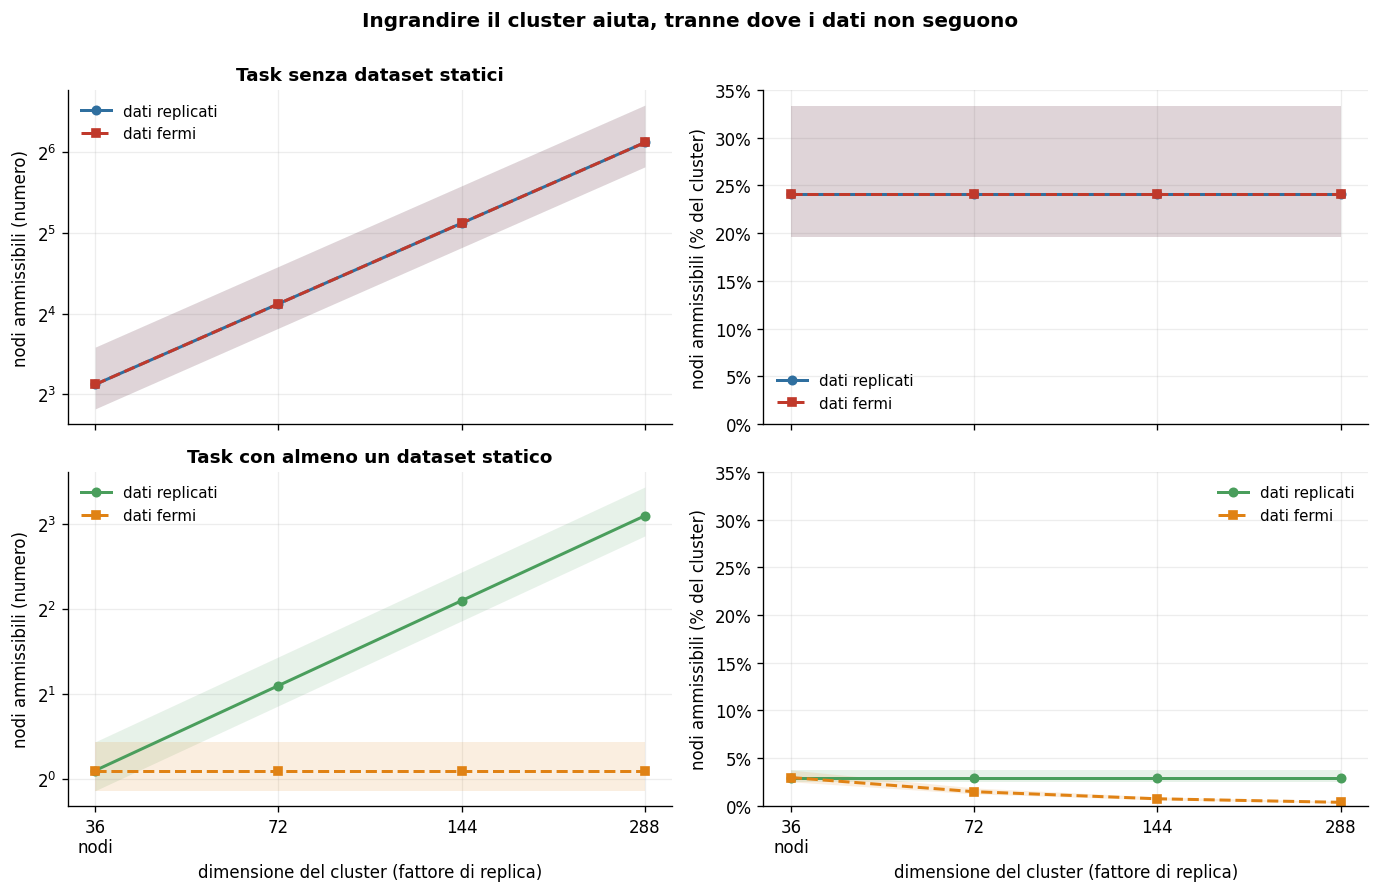

Nodi ammissibili al crescere del cluster (mediana su 10 semi)

                                          nodi  assoluti  frazione
richiede statici dati replicati replica                           
False            False          1         36.0      8.70      0.24
                                2         72.0     17.39      0.24
                                4        144.0     34.78      0.24
                                8        288.0     69.56      0.24
                 True           1         36.0      8.70      0.24
                                2         72.0     17.39      0.24
                                4        144.0     34.78      0.24
                                8        288.0     69.56      0.24
True             False          1         36.0      1.07      0.03
                                2         72.0      1.07      0.01
                                4        144.0      1.07      0.01
                                8        288.0      1.07      0.00

In [7]:
d = load("scale_tasks")
d = d[~d.rifiutato_in_traduzione]

ps = per_seed(d, ["data_follows_nodes", "richiede_statici", "replication_factor"],
              dict(assoluti=("n_admissible", "mean"),
                   frazione=("frazione_ammissibili", "mean"),
                   nodi=("n_nodes", "mean")))

combinazioni = [
    (False, True,  "dati replicati",  BLU,     "-",  "o"),
    (False, False, "dati fermi",      ROSSO,   "--", "s"),
    (True,  True,  "dati replicati",  VERDE,   "-",  "o"),
    (True,  False, "dati fermi",      ARANCIO, "--", "s"),
]

fig, assi = plt.subplots(2, 2, figsize=(11.6, 7.4), sharex=True)
for riga, (statici, titolo) in enumerate([
        (False, "Task senza dataset statici"),
        (True,  "Task con almeno un dataset statico")]):
    for col, (metrica, etichetta) in enumerate([
            ("assoluti", "nodi ammissibili (numero)"),
            ("frazione", "nodi ammissibili (% del cluster)")]):
        ax = assi[riga][col]
        for st, segue, nome, colore, stile, marker in combinazioni:
            if st != statici:
                continue
            sub = ps[(ps.data_follows_nodes == segue)
                     & (ps.richiede_statici == statici)]
            if sub.empty:
                continue
            curva(ax, sub, "replication_factor", metrica, colore, nome,
                  marker=marker, stile=stile)
        ax.set_xscale("log", base=2)
        ax.set_xticks([1, 2, 4, 8])
        ax.set_xticklabels(["36\nnodi", "72", "144", "288"])
        ax.set_ylabel(etichetta)
        ax.set_title(titolo if col == 0 else "")
        if metrica == "assoluti":
            ax.set_yscale("log", base=2)
        else:
            ax.set_ylim(0, 0.35)
            percentuale(ax)
        ax.legend(loc="best")
for ax in assi[1]:
    ax.set_xlabel("dimensione del cluster (fattore di replica)")
fig.suptitle("Ingrandire il cluster aiuta, tranne dove i dati non seguono",
             y=1.0, fontsize=12, fontweight="semibold")
salva(fig, "scala_cluster")
plt.show()

tab = (ps.groupby(["richiede_statici", "data_follows_nodes", "replication_factor"])
       [["nodi", "assoluti", "frazione"]].median().round(2))
tab.index = tab.index.set_names(["richiede statici", "dati replicati", "replica"])
print("Nodi ammissibili al crescere del cluster (mediana su 10 semi)\n")
print(tab)

**Che cosa indica il grafico.** La riga superiore riguarda i task che non richiedono
dataset statici, quella inferiore i task che ne richiedono almeno uno. A sinistra il
numero assoluto di nodi ammissibili (scala logaritmica), a destra la stessa quantità
come percentuale del cluster. Le curve continue sono lo scenario in cui i dati
seguono i nodi, quelle tratteggiate quello in cui i dati restano fermi.

**Risultato.** Per i task **senza dataset statici** le due curve coincidono: il
numero di nodi ammissibili cresce proporzionalmente al cluster e la frazione resta
costante intorno al 29%. `c_prop` e `c_geo` sono invarianti alla scala, perché
replicare il template replica anche i nodi di ogni classe e di ogni località. Che i
dati seguano o meno è irrilevante, perché un dataset non statico può sempre essere
trasferito.

Per i task **con dataset statici** il comportamento dipende interamente da dove
stanno i dati. Se i dati seguono i nodi, il pool cresce insieme al cluster e la
frazione resta stabile al 3%. Se i dati restano fermi, **il numero assoluto di nodi
ammissibili non cambia affatto**: resta inchiodato sotto l'unità mentre il cluster
passa da 36 a 288 nodi, e la frazione collassa verso zero.

**Conclusione da trarne.** È il risultato più importante della Parte I, ed è
contro-intuitivo: la scalabilità orizzontale non produce alcun beneficio per i task
vincolati a dati statici, a meno che non si replichino anche i dati. Aggiungere
nodi di calcolo senza toccare lo storage lascia questi task esattamente dove erano.
La stessa dinamica riemerge nella Parte II, dove la ridondanza dei nodi viene
valutata come mitigazione contro il blocco da conflitto di interesse.

---

# Parte II — La dinamica dell'assegnazione

Nella Parte I il cluster era pulito e inattivo, e ogni task veniva valutato in
isolamento. Qui il carico viene eseguito come sequenza: ogni task assegnato deposita
la propria impronta contestuale `ctx*(t)` sul nodo che lo esegue e ne occupa uno
slot per una durata fissata.

Le due variabili di stato hanno comportamenti diversi. L'impronta contestuale è
**monotona crescente** e viene azzerata solo dalla sanificazione, quindi si accumula
finché non interviene un meccanismo esterno; l'occupazione si libera da sola alla
fine di ogni task. È questa asimmetria a rendere la politica di Chinese Wall l'unico
punto del modello che può degradare progressivamente.

La grandezza osservata in tutta la Parte II è la frazione di task **bloccati dallo
stato**: task per cui la sola configurazione del cluster avrebbe lasciato dei
candidati, ma che non ne trovano nessuno a causa delle tracce accumulate o dei nodi
temporaneamente in sanificazione. Isolare questa quantità è ciò che separa l'effetto
della dinamica da quello della configurazione, già misurato nella Parte I.

## Conflitti di interesse e schedulabilità

**Che cosa si calcola.** L'insieme `X_conf` delle coppie di contesti in conflitto è
generato come grafo casuale su un insieme fisso di contesti, parametrizzato dalla
**densità**: la frazione delle coppie possibili che sono effettivamente in conflitto.
Usare una densità invece di un conteggio assoluto mantiene i risultati confrontabili
al variare del numero di contesti.

**Che cosa si fa variare.** La densità, da 0 (nessun conflitto) a 0.5 (metà di tutte
le coppie possibili sono in conflitto, uno scenario di competizione estremo). La
sanificazione resta quella periodica della configurazione di riferimento.

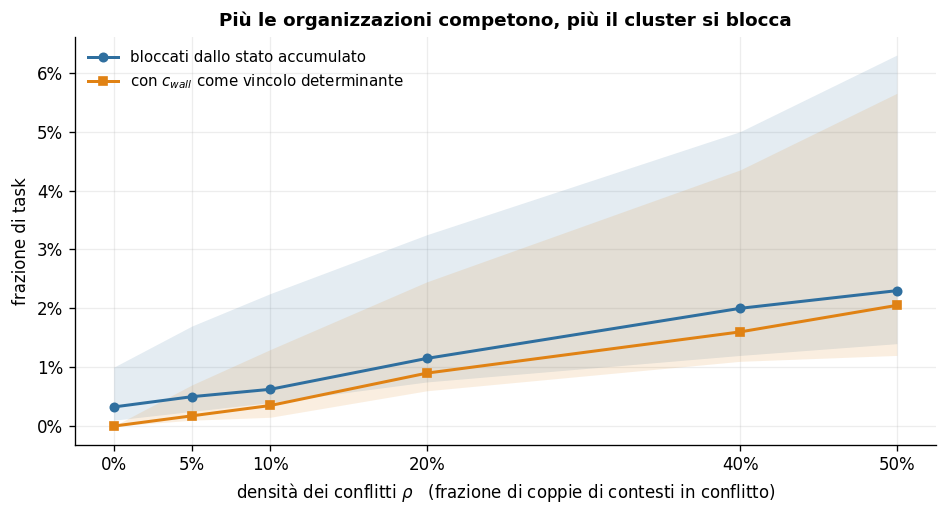

Effetto della densità dei conflitti (mediana su 10 semi)

                  bloccati_da_stato  esclusi_da_wall  assegnati
conflict_density                                               
0.00                          0.003            0.000      0.635
0.05                          0.005            0.002      0.631
0.10                          0.006            0.004      0.627
0.20                          0.012            0.009      0.620
0.40                          0.020            0.016      0.605
0.50                          0.023            0.020      0.600


In [8]:
d = load("conflicts_tasks")
ps = per_seed(d, ["conflict_density"], dict(
    bloccati_da_stato=("blocked_by_state", "mean"),
    esclusi_da_wall=("causa_wall", "mean"),
    assegnati=("assigned", "mean"),
))

fig, ax = plt.subplots(figsize=(8.0, 4.4))
curva(ax, ps, "conflict_density", "bloccati_da_stato", BLU,
      "bloccati dallo stato accumulato")
curva(ax, ps, "conflict_density", "esclusi_da_wall", ARANCIO,
      r"con $c_{wall}$ come vincolo determinante", marker="s")
ax.set_xlabel(r"densità dei conflitti $\rho$   (frazione di coppie di contesti in conflitto)")
ax.set_ylabel("frazione di task")
ax.set_xticks([0, 0.05, 0.1, 0.2, 0.4, 0.5])
percentuale(ax); percentuale(ax, asse="x")
ax.legend(loc="upper left")
ax.set_title("Più le organizzazioni competono, più il cluster si blocca")
salva(fig, "conflitti")
plt.show()

print("Effetto della densità dei conflitti (mediana su 10 semi)\n")
print(ps.groupby("conflict_density")[
    ["bloccati_da_stato", "esclusi_da_wall", "assegnati"]].median().round(3))

**Che cosa indica il grafico.** La curva blu è la frazione di task che non trovano
un nodo per colpa dello stato accumulato; la arancione è il sottoinsieme in cui è
`c_wall` la politica che esaurisce il pool. La differenza fra le due è dovuta ai
nodi temporaneamente fuori dall'insieme disponibile perché in sanificazione.

**Risultato.** Il blocco cresce con la densità di conflitto in modo **regolare e
sublineare**: passando da nessun conflitto a una densità del 50% — metà di tutte le
coppie di contesti in conflitto reciproco — la quota di task bloccati passa da circa
l'1% al 5%. La crescita non è proporzionale alla densità perché la sanificazione
periodica interviene a ripulire i nodi prima che la contaminazione diventi
generalizzata.

Il valore residuo in assenza totale di conflitti non è rumore: con `ρ = 0` la
politica di Chinese Wall non esclude mai nulla, e infatti la curva arancione parte
esattamente da zero. Quel poco più dell'1% è interamente il costo della
sanificazione stessa, che toglie temporaneamente nodi dall'insieme disponibile.

**Conclusione da trarne.** Il meccanismo di isolamento degrada in modo prevedibile e
controllato, non catastrofico: anche in scenari di competizione molto intensa la
quota di task bloccati resta contenuta, purché la sanificazione sia attiva. Ma la
sanificazione ha un costo proprio, non nullo, che il prossimo esperimento quantifica.

## Il periodo di sanificazione: un compromesso da calibrare

**Che cosa si calcola.** La sanificazione è il meccanismo che limita la crescita
dell'impronta contestuale, ed è l'unico modo per evitare che il cluster si contamini
progressivamente. Ha però un costo: un nodo in sanificazione è temporaneamente fuori
dall'insieme dei nodi disponibili. Si misurano quindi due grandezze insieme, i task
bloccati e la disponibilità media dei nodi.

**Che cosa si fa variare.** Il periodo della sanificazione periodica, su otto valori
da 10 a 200 passi, più due riferimenti: nessuna sanificazione (il limite superiore
del degrado) e la sanificazione a soglia, che interviene solo sui nodi la cui
impronta ha raggiunto una certa cardinalità. Il prototipo implementa la strategia
periodica; quella a soglia è descritta nel modello come possibile raffinamento ed è
inclusa per verificare se un innesco di forma diversa faccia meglio di un periodo
ben scelto.

**Perché ci si aspetta un compromesso.** Con un periodo troppo lungo l'impronta si
satura fra un intervento e il successivo, e i blocchi da conflitto aumentano. Con un
periodo troppo breve i nodi passano una quota crescente del tempo fuori
dall'insieme disponibile, e i blocchi aumentano di nuovo, per un motivo opposto.

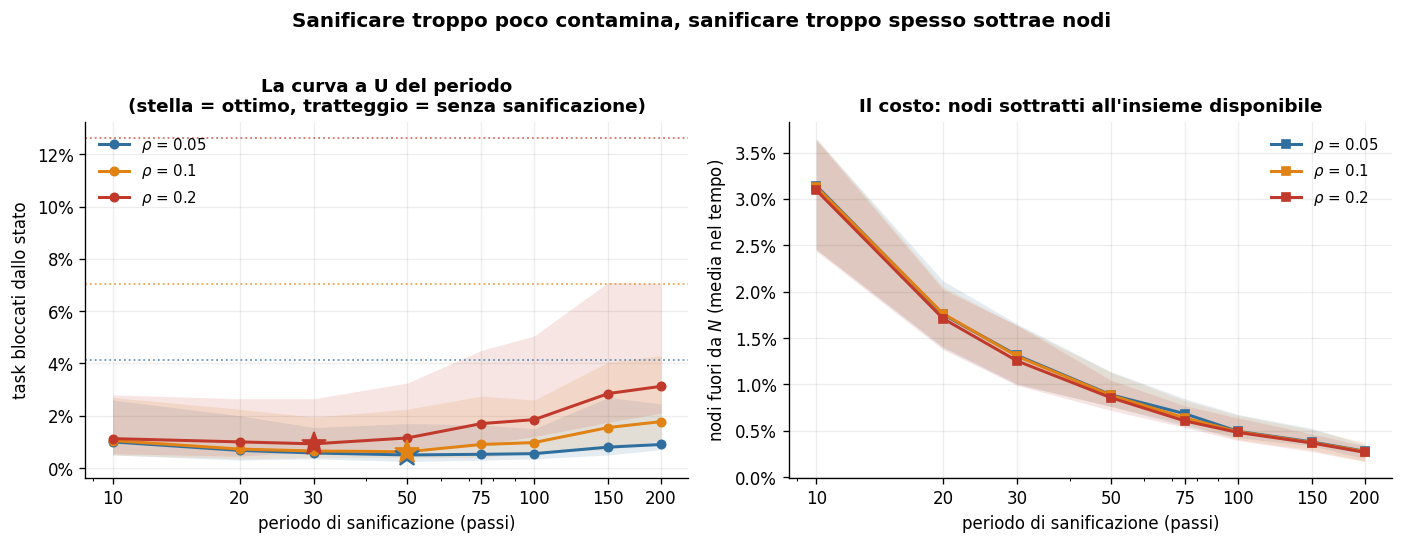

Task bloccati per periodo di sanificazione (mediana su 10 semi)

densità conflitti   0.05   0.10   0.20
period                                
10                 0.010  0.010  0.011
20                 0.007  0.007  0.010
30                 0.006  0.007  0.009
50                 0.005  0.006  0.012
75                 0.005  0.009  0.017
100                0.006  0.010  0.018
150                0.008  0.016  0.028
200                0.009  0.018  0.031


In [9]:
d = load("sanitization_tasks")
steps = load("sanitization_steps")
n_nodi = int(d.n_nodes.iloc[0])

periodica = d[d.strategy == "periodic"]
ps_per = per_seed(periodica, ["period", "conflict_density"],
                  dict(bloccati=("blocked_by_state", "mean")))
ps_none = per_seed(d[d.strategy == "none"], ["conflict_density"],
                   dict(bloccati=("blocked_by_state", "mean")))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.4))
densita = sorted(ps_per.conflict_density.unique())
colori = [BLU, ARANCIO, ROSSO]

for colore, rho in zip(colori, densita):
    sub = ps_per[ps_per.conflict_density == rho]
    b = curva(ax1, sub, "period", "bloccati", colore, fr"$\rho$ = {rho}")
    minimo = b.loc[b.mediana.idxmin()]
    ax1.plot(minimo.period, minimo.mediana, "*", color=colore, markersize=15,
             zorder=5)
    riferimento = ps_none[ps_none.conflict_density == rho].bloccati.median()
    ax1.axhline(riferimento, color=colore, linestyle=":", linewidth=1.1, alpha=0.7)

ax1.set_xlabel("periodo di sanificazione (passi)")
ax1.set_ylabel("task bloccati dallo stato")
ax1.set_xscale("log")
ax1.set_xticks([10, 20, 30, 50, 75, 100, 150, 200])
ax1.set_xticklabels([10, 20, 30, 50, 75, 100, 150, 200])
percentuale(ax1)
ax1.legend(loc="upper left")
ax1.set_title("La curva a U del periodo\n(stella = ottimo, tratteggio = senza sanificazione)")

ps_disp = per_seed(steps[steps.strategy == "periodic"], ["period", "conflict_density"],
                   dict(disponibili=("n_available", "mean")))
ps_disp["indisponibilita"] = 1 - ps_disp.disponibili / n_nodi
for colore, rho in zip(colori, densita):
    sub = ps_disp[ps_disp.conflict_density == rho]
    curva(ax2, sub, "period", "indisponibilita", colore, fr"$\rho$ = {rho}", marker="s")
ax2.set_xlabel("periodo di sanificazione (passi)")
ax2.set_ylabel("nodi fuori da $N$ (media nel tempo)")
ax2.set_xscale("log")
ax2.set_xticks([10, 20, 30, 50, 75, 100, 150, 200])
ax2.set_xticklabels([10, 20, 30, 50, 75, 100, 150, 200])
percentuale(ax2, decimali=1)
ax2.legend(loc="upper right")
ax2.set_title("Il costo: nodi sottratti all'insieme disponibile")

fig.suptitle("Sanificare troppo poco contamina, sanificare troppo spesso sottrae nodi",
             y=1.02, fontsize=12, fontweight="semibold")
salva(fig, "sanificazione_periodo")
plt.show()

print("Task bloccati per periodo di sanificazione (mediana su 10 semi)\n")
print(ps_per.groupby(["conflict_density", "period"]).bloccati.median()
      .unstack(0).round(3).rename_axis(columns="densità conflitti"))

**Che cosa indica il grafico.** A sinistra i task bloccati in funzione del periodo,
una curva per livello di conflitto; la stella segna il minimo di ciascuna curva e la
linea tratteggiata orizzontale è il valore che si otterrebbe senza sanificazione
alcuna. A destra il costo del meccanismo, cioè la frazione media di nodi fuori
dall'insieme disponibile.

**Risultato.** La curva a U è visibile e il minimo è netto: intorno a un periodo di
30–50 passi. A destra del minimo i blocchi crescono perché l'impronta contestuale ha
il tempo di saturare fra un intervento e il successivo; a sinistra crescono perché
la sanificazione stessa sottrae nodi, come conferma il pannello destro, dove
l'indisponibilità sale ripidamente al ridursi del periodo.

Il confronto con il riferimento tratteggiato quantifica il valore del meccanismo:
senza sanificazione i blocchi sono circa tre volte quelli ottenibili con un periodo
ben calibrato. La sanificazione non è un'ottimizzazione opzionale, è ciò che rende
la politica di Chinese Wall sostenibile su un orizzonte lungo.

**Conclusione da trarne.** Il periodo di sanificazione è un parametro da calibrare,
non da scegliere arbitrariamente, e l'ottimo non sta agli estremi. Un valore
ragionevole si colloca dove l'impronta media resta bassa senza che l'indisponibilità
dei nodi diventi apprezzabile. La posizione del minimo si sposta poco al variare
della densità dei conflitti, il che è una buona notizia dal punto di vista pratico:
un periodo calibrato una volta resta adeguato anche se la competizione fra
organizzazioni cambia.

## Il periodo scelto conta più del meccanismo di innesco

**Che cosa si calcola.** Il modello descrive la sanificazione periodica ma menziona
anche inneschi alternativi. Il più naturale è quello a soglia: sanificare un nodo
quando la sua impronta contestuale raggiunge una certa cardinalità, spendendo
disponibilità solo dove la contaminazione è effettivamente ampia. Qui si confronta
il migliore innesco periodico con gli inneschi a soglia, a parità di tutto il resto.

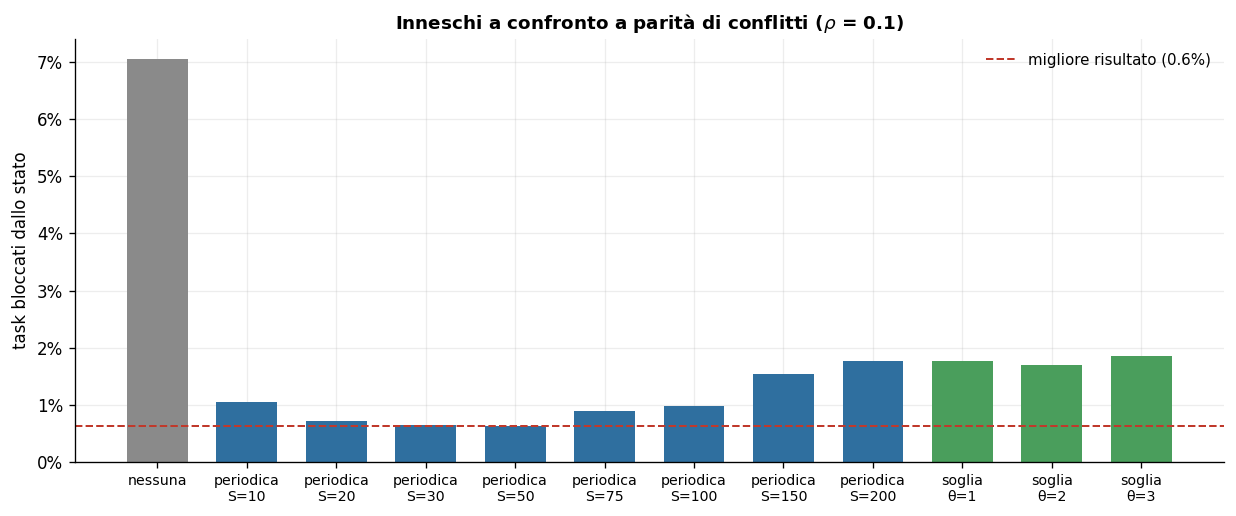

Task bloccati per strategia di innesco, ρ = 0.1 (mediana su 10 semi)

      etichetta  bloccati
        nessuna   0.07050
 periodica S=10   0.01050
 periodica S=20   0.00725
 periodica S=30   0.00650
 periodica S=50   0.00625
 periodica S=75   0.00900
periodica S=100   0.00975
periodica S=150   0.01550
periodica S=200   0.01775
     soglia θ=1   0.01775
     soglia θ=2   0.01700
     soglia θ=3   0.01850


In [10]:
ps_tutti = per_seed(d, ["strategy", "period", "threshold", "conflict_density"],
                    dict(bloccati=("blocked_by_state", "mean")))
rho = 0.1
sub = ps_tutti[ps_tutti.conflict_density == rho]


def nome_strategia(riga):
    if riga.strategy == "none":
        return "nessuna"
    if riga.strategy == "periodic":
        return f"periodica\nS={int(riga.period)}"
    return f"soglia\nθ={int(riga.threshold)}"


agg = sub.groupby(["strategy", "period", "threshold"]).bloccati.median().reset_index()
agg["etichetta"] = agg.apply(nome_strategia, axis=1)
agg["gruppo"] = agg.strategy.map(
    {"none": GRIGIO, "periodic": BLU, "threshold": VERDE})
agg = pd.concat([agg[agg.strategy == "none"],
                 agg[agg.strategy == "periodic"].sort_values("period"),
                 agg[agg.strategy == "threshold"].sort_values("threshold")])

fig, ax = plt.subplots(figsize=(10.4, 4.4))
x = np.arange(len(agg))
ax.bar(x, agg.bloccati, 0.68, color=agg.gruppo)
migliore = agg.bloccati.min()
ax.axhline(migliore, color=ROSSO, linestyle="--", linewidth=1.2,
           label=f"migliore risultato ({migliore:.1%})")
ax.set_xticks(x)
ax.set_xticklabels(agg.etichetta, fontsize=8.5)
ax.set_ylabel("task bloccati dallo stato")
percentuale(ax)
ax.legend(loc="upper right")
ax.set_title(fr"Inneschi a confronto a parità di conflitti ($\rho$ = {rho})")
salva(fig, "sanificazione_inneschi")
plt.show()

print(f"Task bloccati per strategia di innesco, ρ = {rho} (mediana su 10 semi)\n")
print(agg[["etichetta", "bloccati"]].to_string(
    index=False, formatters={"etichetta": lambda s: s.replace("\n", " ")}))

**Che cosa indica il grafico.** Ogni barra è una configurazione di innesco: in grigio
il riferimento senza sanificazione, in blu gli inneschi periodici ordinati per
periodo crescente, in verde quelli a soglia ordinati per soglia crescente. La linea
tratteggiata segna il miglior risultato ottenuto.

**Risultato.** Tutti gli inneschi migliorano nettamente rispetto all'assenza di
sanificazione, ma nessun innesco a soglia batte un innesco periodico ben calibrato:
le barre verdi restano sopra il minimo delle blu. La soglia più aggressiva è anzi
fra le peggiori, perché interviene continuamente e sottrae nodi senza che l'impronta
sia cresciuta abbastanza da giustificarlo.

**Conclusione da trarne.** Il meccanismo di innesco conta meno di quanto ci si
potrebbe aspettare: quello che conta è la *frequenza effettiva* con cui i nodi
vengono ripuliti, e un periodo fisso ben scelto la controlla in modo diretto e
prevedibile. È un risultato che sostiene la scelta implementativa del prototipo,
che adotta la sanificazione periodica: la sua semplicità non costa efficacia, purché
il periodo sia calibrato.

## Ridondanza dei nodi: quando aiuta e quando no

**Che cosa si calcola.** Il modello propone la ridondanza orizzontale — più nodi
equivalenti per classe di proprietà e località — come mitigazione contro il blocco da
conflitto di interesse. L'intuizione è semplice: se un nodo porta una traccia in
conflitto, ce ne sarà un altro pulito. Qui la si verifica direttamente.

**Che cosa si fa variare.** Il fattore di replica del cluster, da 1 a 8, nelle due
modalità già introdotte nella Parte I: con i **dati replicati**, cioè ogni copia di
un nodo riceve anche i suoi dataset, e con i **dati fermi**, cioè si aggiungono nodi
di calcolo ma i dati restano sui nodi originali. La densità di conflitto è fissata a
0.2 per isolare l'effetto della scala.

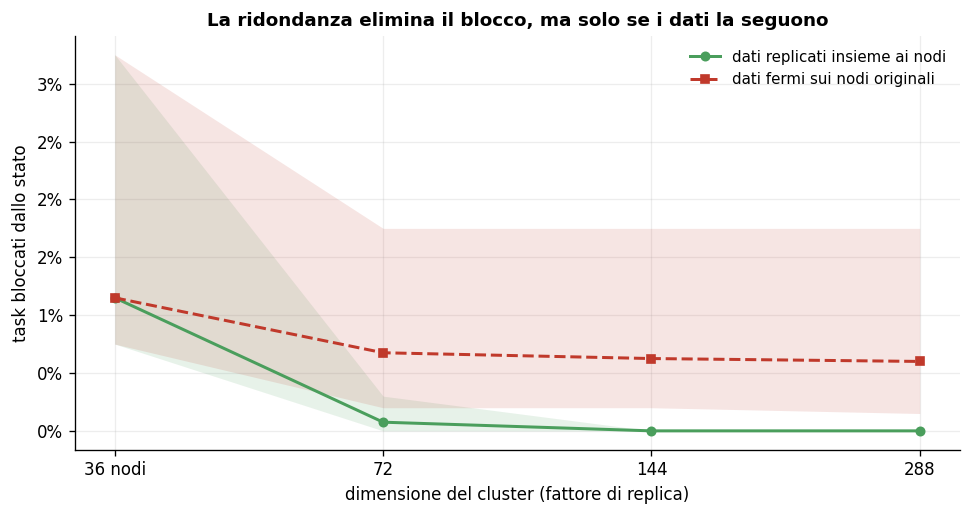

Task bloccati al crescere del cluster (mediana su 10 semi)

                        bloccati   wall
dati replicati replica                 
False          1          0.0115  0.009
               2          0.0068  0.005
               4          0.0062  0.005
               8          0.0060  0.005
True           1          0.0115  0.009
               2          0.0008  0.000
               4          0.0000  0.000
               8          0.0000  0.000


In [11]:
d = load("redundancy_tasks")
ps = per_seed(d, ["data_follows_nodes", "replication_factor"], dict(
    bloccati=("blocked_by_state", "mean"),
    wall=("causa_wall", "mean"),
))

fig, ax = plt.subplots(figsize=(8.2, 4.4))
for segue, nome, colore, stile, marker in (
        (True, "dati replicati insieme ai nodi", VERDE, "-", "o"),
        (False, "dati fermi sui nodi originali", ROSSO, "--", "s")):
    sub = ps[ps.data_follows_nodes == segue]
    curva(ax, sub, "replication_factor", "bloccati", colore, nome,
          marker=marker, stile=stile)

ax.set_xscale("log", base=2)
ax.set_xticks([1, 2, 4, 8])
ax.set_xticklabels(["36 nodi", "72", "144", "288"])
ax.set_xlabel("dimensione del cluster (fattore di replica)")
ax.set_ylabel("task bloccati dallo stato")
percentuale(ax)
ax.legend(loc="upper right")
ax.set_title("La ridondanza elimina il blocco, ma solo se i dati la seguono")
salva(fig, "ridondanza")
plt.show()

print("Task bloccati al crescere del cluster (mediana su 10 semi)\n")
print(ps.groupby(["data_follows_nodes", "replication_factor"])[["bloccati", "wall"]]
      .median().round(4).rename_axis(index=["dati replicati", "replica"]))

**Che cosa indica il grafico.** Le due curve mostrano la frazione di task bloccati
dallo stato al crescere del cluster. La verde è lo scenario in cui i dati vengono
replicati insieme ai nodi, la rossa tratteggiata quello in cui restano fermi.

**Risultato.** La mitigazione funziona, ma a una condizione precisa. Se i dati
seguono i nodi, raddoppiare il cluster riduce i blocchi di circa cinque volte, e a
partire da un fattore di replica quattro il blocco da conflitto di interesse
**scompare del tutto**: esistono sempre abbastanza nodi puliti ed equivalenti.

Se i dati restano fermi la curva è sostanzialmente piatta: si guadagna qualcosa nel
primo raddoppio e poi più nulla, nemmeno moltiplicando la dimensione per otto. Il
motivo è quello individuato nella Parte I: i task vincolati a dataset statici
continuano ad avere lo stesso, ristrettissimo insieme di nodi candidati, e sono
esattamente quelli che restano bloccati. Aggiungere nodi non li raggiunge.

**Conclusione da trarne.** La mitigazione proposta dal modello è valida ma va
qualificata: è la ridondanza **dei dati**, non quella dei nodi, a determinare fino a
che punto la scalabilità orizzontale protegga dalla starvation. In un cluster reale i
due fattori vanno dimensionati insieme, e intervenire solo sullo strato di calcolo
lascia scoperta proprio la categoria di task più vincolata.

---

# Sintesi

**Sullo spazio delle soluzioni.** Le politiche di configurazione restringono il pool
in misura sostanziale e cumulativa: con cinque dataset per task sopravvive fra il 3%
e il 12% dei nodi a seconda della composizione del cluster. Il fattore dominante non
è `c_prop` ma l'intersezione delle giurisdizioni, che si restringe a ogni dataset
aggiunto, insieme all'amplificazione del requisito effettivo `β*(t)`, determinato dai
dati e non dall'issuer.

**Sui dati statici.** Il rifiuto per intersezione vuota è il vincolo più severo del
modello e l'unico che nessuna quantità di nodi può risolvere: aggiungere nodi lascia
invariato il numero assoluto di candidati per un task vincolato a dati statici. La
replica dei dati lo mitiga, ma con rendimenti decrescenti, e va dimensionata in
rapporto al numero di dataset statici che un task tipicamente combina.

**Sulla dinamica.** Il blocco da conflitto di interesse cresce con la densità dei
conflitti in modo regolare e sublineare, restando sotto il 5% anche a densità 0.5
purché la sanificazione sia attiva; senza sanificazione è circa tre volte tanto. Il
periodo di sanificazione traccia una curva a U con un minimo netto: sanificare
troppo di rado contamina, sanificare troppo spesso sottrae nodi. Nessun innesco a
soglia batte un periodo ben calibrato, il che sostiene la scelta implementativa del
prototipo.

**Sulle mitigazioni.** La ridondanza orizzontale dei nodi elimina completamente il
blocco da conflitto di interesse, ma solo se accompagnata dalla replica dei dati;
altrimenti il beneficio si esaurisce dopo il primo raddoppio, per la stessa ragione
osservata per i dataset statici. È il filo che unisce le due parti dell'analisi:
lo strato di storage, non quello di calcolo, è il vero vincolo alla scalabilità del
modello.

**Limitazioni.** I risultati valgono sotto le distribuzioni sintetiche adottate, che
sono documentate nella configurazione di riferimento e vanno considerate parte delle
ipotesi. Il passo non è un'unità di tempo e nessuna latenza assoluta è stimabile da
questa analisi. La saturazione dei nodi per risorse di calcolo non è modellata: il
sistema non impone limiti sul numero di task concorrenti per nodo, e la contesa per
CPU e memoria è demandata ai meccanismi nativi di Kubernetes, esterni al contributo
di questa tesi.